# Autoencoder — One-Class Classification

The model learns **only good strokes**, then asks of a new one: *close enough to what I know?*

## Table of Contents

1. [Model Selection](#model-selection)
2. [Setup](#setup)
3. [Feature Engineering](#feature-engineering)
4. [Train / Validation / Test Split](#train-validation-test-split)
5. [Implementation](#implementation)
6. [Evaluation Metrics](#evaluation-metrics)
7. [Hyperparameter Tuning](#hyperparameter-tuning)
8. [Validation on Unseen Recordings](#validation-on-unseen-recordings)
9. [Comparative Analysis](#comparative-analysis)
10. [Next Steps](#next-steps)

<a id="model-selection"></a>
## Model Selection

```
Input --> [ENCODER] --> Bottleneck --> [DECODER] --> Reconstruction
```

Good strokes rebuild accurately; anything unfamiliar yields a high **reconstruction error** — the anomaly score.

**Why one-class?** The [baseline](../2_BaselineModel/baseline_model.ipynb) trained on both classes, but only 79 of 657 strokes are bad, all from one rower. Rather than fight that imbalance with class weights, this model sidesteps it: it fits on good strokes alone, so the small class is only needed for evaluation.

**Why LSTM?** A stroke is a sequence (catch → drive → finish) where the rhythm matters; Conv1D would only catch local patterns.

<a id="setup"></a>
## Setup

`RANDOM_STATE` seeds NumPy and TensorFlow; `PROJECT_ROOT` / `NORM_DIR` resolve paths relative to the repo.

In [1]:
!pip install tensorflow optuna -q


[notice] A new release of pip is available: 23.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, precision_recall_curve
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'requirements.txt').exists()
)
NORM_DIR = PROJECT_ROOT / '1_DatasetCharacteristics' / 'landmarks' / 'normalized'

print('TensorFlow:', tf.__version__)
print('Project root:', PROJECT_ROOT)


TensorFlow: 2.21.0
Project root: /Users/clarabrilke/ML projects/ML-project


/Users/clarabrilke/.pyenv/versions/3.11.4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id="feature-engineering"></a>
## Feature Engineering

- Strokes vary in length → all resampled to `TARGET_LEN`
- `phase`, `GOOD`, `BAD` excluded → the model reconstructs movement, not labels
- Training uses `X_good_seq` only; `X_bad_seq` is held back for evaluation

In [3]:
EXCLUDE_COLS = {'phase', 'GOOD', 'BAD'}

def resample_seq(seq, target_len):
    x_old = np.linspace(0, 1, len(seq))
    x_new = np.linspace(0, 1, target_len)
    return interp1d(x_old, seq, axis=0)(x_new)

def load_strokes_for_video(video_stem): 
    lm_path     = NORM_DIR / f'{video_stem}-landmarks-norm_10fps.csv'
    stroke_path = NORM_DIR / f'{video_stem}-strokes.csv'
    landmarks   = pd.read_csv(lm_path)
    strokes     = pd.read_csv(stroke_path)
    feature_cols = [c for c in landmarks.columns if c not in EXCLUDE_COLS]
    X = landmarks[feature_cols].values

    # strokes.csv stores frame numbers from the original video (~30fps).
    # The landmarks file is downsampled to 10fps (~factor 3).
    fps_ratio = max(1, round(strokes['endzug_end'].max() / len(landmarks)))

    seqs = []
    for _, row in strokes.iterrows():
        start = int(row['endzug_start'] / fps_ratio)
        end   = int(row['endzug_end']   / fps_ratio)
        seq   = X[start:end]
        if len(seq) >= 10:
            seqs.append(seq)
    return seqs, feature_cols, fps_ratio

# --- Load all stroke files ---
stroke_files = sorted(NORM_DIR.glob('*-strokes.csv'))
# stroke_files = [f for f in stroke_files if not f.stem.startswith('sim')]  # exclude Simon's videos

# Single pass: load raw sequences, collect lengths, print summary
raw          = {}   # video_stem -> (seqs, feature_cols, fps_ratio)
all_lengths  = []
feature_cols = None

print(f'Videos found: {len(stroke_files)}')
for sf in stroke_files:
    video_stem = sf.stem.replace('-strokes', '')
    label = 'BAD ' if 'BAD' in video_stem.upper() else 'GOOD'
    seqs, fcols, ratio = load_strokes_for_video(video_stem)
    if feature_cols is None:
        feature_cols = fcols
    raw[video_stem] = (seqs, ratio)
    all_lengths.extend(len(s) for s in seqs)
    print(f'  [{label}]  {video_stem}: {len(seqs)} strokes (fps_ratio={ratio})')

TARGET_LEN = int(np.median(all_lengths))
print(f'\nStroke lengths (10fps) -- min: {min(all_lengths)}  median: {TARGET_LEN}  max: {max(all_lengths)}')
print(f'TARGET_LEN = {TARGET_LEN} frames')

# Resample and sort into good / bad
good_seqs, bad_seqs = [], []
for video_stem, (seqs, _) in raw.items():
    resampled = [resample_seq(s, TARGET_LEN) for s in seqs]
    if 'BAD' in video_stem.upper():
        bad_seqs.extend(resampled)
    else:
        good_seqs.extend(resampled) 

X_good_seq = np.array(good_seqs)
X_bad_seq  = np.array(bad_seqs)

print(f'\nGood strokes: {X_good_seq.shape}  (n_sequences, frames, features)')
print(f'Bad strokes:  {X_bad_seq.shape}')


Videos found: 11
  [BAD ]  cla-BAD-2: 59 strokes (fps_ratio=1)
  [BAD ]  cla-BAD: 20 strokes (fps_ratio=1)
  [GOOD]  cla-GOOD-fast: 87 strokes (fps_ratio=1)
  [GOOD]  cla-GOOD-slow-2: 33 strokes (fps_ratio=1)
  [GOOD]  cla-GOOD-slow: 68 strokes (fps_ratio=1)
  [GOOD]  man-GOOD-slow-MIRRORED-7.5min: 147 strokes (fps_ratio=1)
  [GOOD]  mar-GOOD-fast: 61 strokes (fps_ratio=1)
  [GOOD]  mar-GOOD-slow: 50 strokes (fps_ratio=1)
  [GOOD]  sim-GOOD-fast: 45 strokes (fps_ratio=1)
  [GOOD]  sim-GOOD-slow: 76 strokes (fps_ratio=1)
  [GOOD]  sim-GOOD-slow2: 11 strokes (fps_ratio=1)

Stroke lengths (10fps) -- min: 19  median: 27  max: 34
TARGET_LEN = 27 frames

Good strokes: (578, 27, 66)  (n_sequences, frames, features)
Bad strokes:  (79, 27, 66)


<a id="normalization-check"></a>
### Normalization Check

Mediapipe coordinates are already body-relative, so no StandardScaler is needed. Confirm only that values sit in a sane range and that good and bad strokes share the same scale — otherwise the reconstruction error would track a distribution shift instead of movement.

In [4]:
mean_good, std_good = X_good_seq.mean().round(4), X_good_seq.std().round(4)
mean_bad,  std_bad  = X_bad_seq.mean().round(4),  X_bad_seq.std().round(4)

print(f'Good strokes -- Mean: {mean_good}  Std: {std_good}')
print(f'Bad strokes  -- Mean: {mean_bad}   Std: {std_bad}')

# --- Automated interpretation ---
mean_diff = abs(mean_good - mean_bad)
std_diff  = abs(std_good  - std_bad)
scale_ok  = max(abs(mean_good), abs(mean_bad)) < 5 and max(std_good, std_bad) < 5
align_ok  = mean_diff < 0.1 and std_diff < 0.1

print()
if scale_ok:
    print('OK  Values are in a reasonable range -- no StandardScaler needed.')
else:
    print('WARN  Values are large -- consider adding a StandardScaler.')

if align_ok:
    print(f'OK  Good and bad strokes are on the same scale '
          f'(mean diff={mean_diff:.4f}, std diff={std_diff:.4f}).')
else:
    print(f'WARN  Scale mismatch between good and bad strokes '
          f'(mean diff={mean_diff:.4f}, std diff={std_diff:.4f}) -- '
          f'reconstruction error may reflect scale, not movement quality.')


Good strokes -- Mean: -0.4768  Std: 0.6458
Bad strokes  -- Mean: -0.4518   Std: 0.6208

OK  Values are in a reasonable range -- no StandardScaler needed.
OK  Good and bad strokes are on the same scale (mean diff=0.0250, std diff=0.0250).


<a id="train-validation-test-split"></a>
## Train / Validation / Test Split

The autoencoder must never see a bad stroke during training. `X_good_seq` is ordered by video, so it is shuffled first. Split 70 / 15 / 15: **X_train** trains, **X_val** drives early stopping, **X_test_good** stays untouched until evaluation, where it joins **X_bad_seq**.

In [5]:
stroke_indices  = np.random.permutation(len(X_good_seq))
X_good_shuffled = X_good_seq[stroke_indices]

n_train = int(len(X_good_shuffled) * 0.70)
n_val   = int(len(X_good_shuffled) * 0.15)

X_train     = X_good_shuffled[:n_train]
X_val       = X_good_shuffled[n_train:n_train + n_val]
X_test_good = X_good_shuffled[n_train + n_val:]

print(f'Train:            {X_train.shape[0]} sequences')
print(f'Validation:       {X_val.shape[0]} sequences  (early stopping only)')
print(f'Test (good):      {X_test_good.shape[0]} sequences')
print(f'Test (bad):       {X_bad_seq.shape[0]} sequences')
print(f'Test (total):     {X_test_good.shape[0] + X_bad_seq.shape[0]} sequences')


Train:            404 sequences
Validation:       86 sequences  (early stopping only)
Test (good):      88 sequences
Test (bad):       79 sequences
Test (total):     167 sequences


<a id="implementation"></a>
## Implementation

| Layer | Output shape | Role |
|---|---|---|
| Input | `(24, 66)` | one stroke |
| LSTM(128) | `(128,)` | encode sequence → single vector |
| Dense(32) | `(32,)` | bottleneck |
| RepeatVector(24) | `(24, 32)` | broadcast across time |
| LSTM(128, return_sequences) | `(24, 128)` | decode |
| TimeDistributed(Dense(66)) | `(24, 66)` | reconstruct each frame |

**Loss:** MSE(input, reconstruction) · **Anomaly score:** mean MSE per sequence.

In [6]:
n_timesteps = TARGET_LEN
n_features  = X_train.shape[2]
LATENT_DIM  = 32

def build_lstm_autoencoder(timesteps, features, latent_dim):
    inputs = keras.Input(shape=(timesteps, features), name='input')

    # Encoder
    x = layers.LSTM(128, return_sequences=False, name='encoder_lstm')(inputs)
    bottleneck = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = layers.RepeatVector(timesteps, name='repeat')(bottleneck)
    x = layers.LSTM(128, return_sequences=True, name='decoder_lstm')(x)
    outputs = layers.TimeDistributed(layers.Dense(features), name='output')(x)

    return keras.Model(inputs, outputs, name='LSTM_Autoencoder')

model = build_lstm_autoencoder(n_timesteps, n_features, LATENT_DIM)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 27, 66)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ (None, 128)            │        99,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 27, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 27, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 27, 66)         │         8,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,914 (761.38 KB)

 Trainable params: 194,914 (761.38 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
EPOCHS     = 50
BATCH_SIZE = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,            # Autoencoder: Input = Target
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.3701 - val_loss: 0.1107
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0983 - val_loss: 0.0870
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0801 - val_loss: 0.0741
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0699 - val_loss: 0.0645
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0625 - val_loss: 0.0584
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0564 - val_loss: 0.0507
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0447 - val_loss: 0.0320
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0283 - val_loss: 0.0205
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0175 - val_loss: 0.0157
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0186 - val_loss: 0.0147
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0153 - val_loss: 0.0144
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

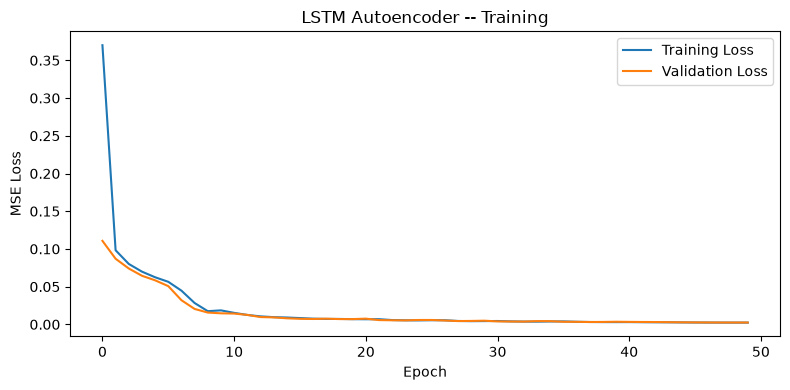

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder -- Training')
ax.legend()
plt.tight_layout()
plt.show()


<a id="evaluation-metrics"></a>
## Evaluation Metrics

<a id="threshold"></a>
### Threshold

The threshold is the **95th percentile** of the training errors — sequences above it count as bad. A higher percentile makes it stricter.

In [9]:
def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1, 2))

train_errors     = reconstruction_error(model, X_train)
test_good_errors = reconstruction_error(model, X_test_good)
bad_errors       = reconstruction_error(model, X_bad_seq)

THRESHOLD_PERCENTILE = 95
threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

print(f'Threshold ({THRESHOLD_PERCENTILE}th percentile of training errors): {threshold:.6f}')
print(f'Mean error -- Train:      {train_errors.mean():.6f}')
print(f'Mean error -- Test (good):{test_good_errors.mean():.6f}')
print(f'Mean error -- Bad:        {bad_errors.mean():.6f}')


Threshold (95th percentile of training errors): 0.003300
Mean error -- Train:      0.002289
Mean error -- Test (good):0.002309
Mean error -- Bad:        0.011786


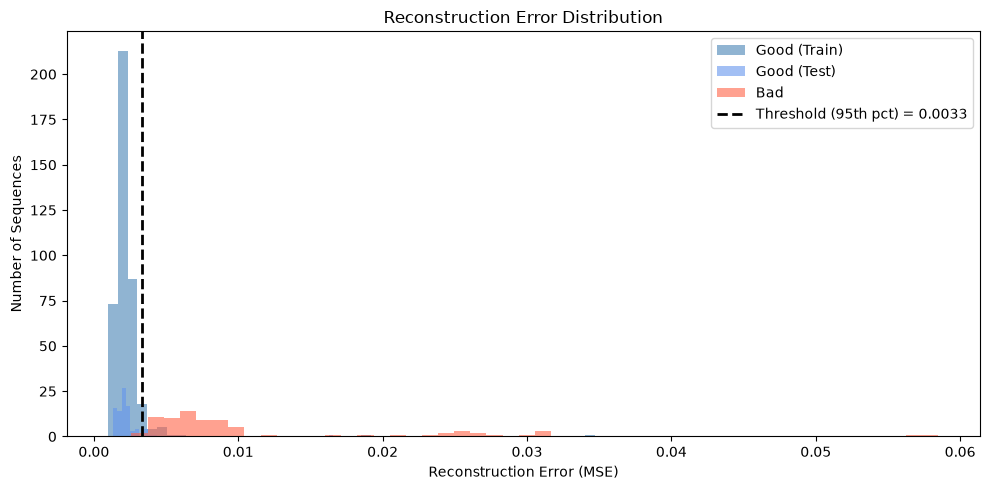

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_errors,      bins=50, alpha=0.6, label='Good (Train)',  color='steelblue')
ax.hist(test_good_errors,  bins=50, alpha=0.6, label='Good (Test)',   color='cornflowerblue')
ax.hist(bad_errors,        bins=50, alpha=0.6, label='Bad',           color='tomato')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({THRESHOLD_PERCENTILE}th pct) = {threshold:.4f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Number of Sequences')
ax.set_title('Reconstruction Error Distribution')
ax.legend()
plt.tight_layout()
plt.show()


<a id="results"></a>
### Results

Held-out good strokes plus all bad strokes; label 1 = bad. A missed bad stroke gives false reassurance, a false alarm only costs trust — so recall matters most.

| Metric | Why |
|---|---|
| **Recall (bad)** | Primary — what share of faults do we catch? |
| **Precision (bad)** | Guards against flagging everything |
| **ROC-AUC** | Headline: the model outputs a score, so the threshold stays tunable |
| **Macro F1** | Weights both classes equally |
| **Accuracy** | Completeness only — predicting "good" throughout scores 0.836 |

ROC-AUC: 0.9872  (threshold-independent)

  Run 1: 95th-pct baseline  (Threshold = 0.003300)
              precision    recall  f1-score   support

        Good       0.99      0.92      0.95        88
         Bad       0.92      0.99      0.95        79

    accuracy                           0.95       167
   macro avg       0.95      0.95      0.95       167
weighted avg       0.95      0.95      0.95       167

  Run 2: F1-optimal  (Threshold = 0.003812)
              precision    recall  f1-score   support

        Good       0.97      0.97      0.97        88
         Bad       0.96      0.96      0.96        79

    accuracy                           0.96       167
   macro avg       0.96      0.96      0.96       167
weighted avg       0.96      0.96      0.96       167



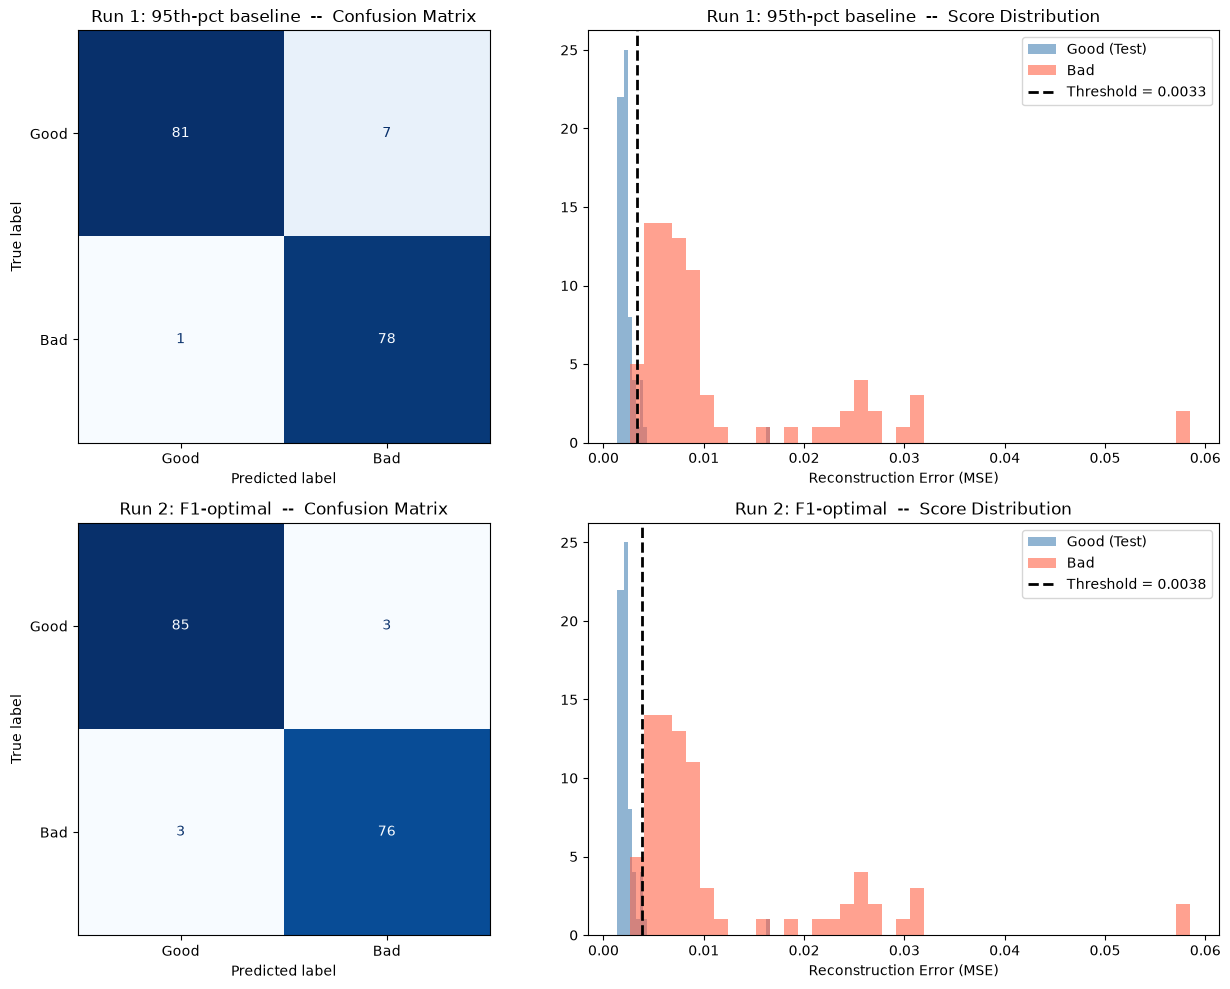

In [11]:
y_scores = np.concatenate([test_good_errors, bad_errors])
y_true   = np.array([0] * len(test_good_errors) + [1] * len(bad_errors))

precision_c, recall_c, thr_c = precision_recall_curve(y_true, y_scores, pos_label=1)
f1_c         = 2 * (precision_c * recall_c) / (precision_c * recall_c + 1e-8)
threshold_f1 = thr_c[np.argmax(f1_c)]

auc = roc_auc_score(y_true, y_scores)
print(f'ROC-AUC: {auc:.4f}  (threshold-independent)\n')

configs = [
    ('95th-pct baseline', threshold),
    ('F1-optimal',        threshold_f1),
]

sep = '=' * 50
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for i, (label, thr) in enumerate(configs):
    y_pred = (y_scores > thr).astype(int)

    print(sep)
    print(f'  Run {i+1}: {label}  (Threshold = {thr:.6f})')
    print(sep)
    print(classification_report(y_true, y_pred, target_names=['Good', 'Bad']))

    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['Good', 'Bad']
    ).plot(ax=axes[i, 0], colorbar=False, cmap='Blues')
    axes[i, 0].set_title(f'Run {i+1}: {label}  --  Confusion Matrix')

    axes[i, 1].hist(test_good_errors, bins=40, alpha=0.6, label='Good (Test)', color='steelblue')
    axes[i, 1].hist(bad_errors,       bins=40, alpha=0.6, label='Bad',         color='tomato')
    axes[i, 1].axvline(thr, color='black', linestyle='--', linewidth=2,
                       label=f'Threshold = {thr:.4f}')
    axes[i, 1].set_xlabel('Reconstruction Error (MSE)')
    axes[i, 1].set_title(f'Run {i+1}: {label}  --  Score Distribution')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


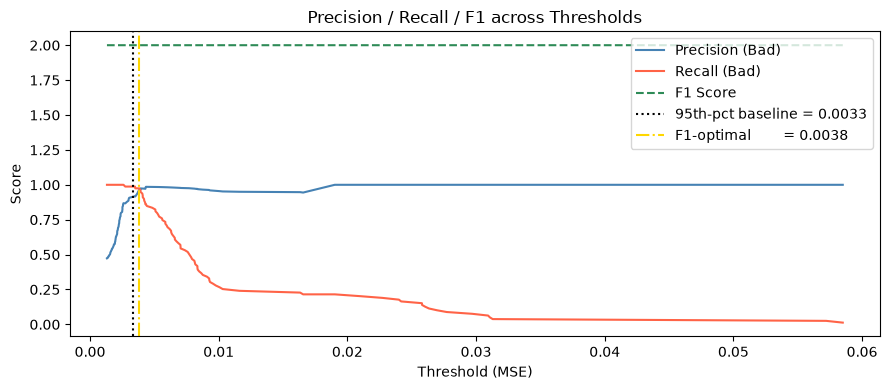

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thr_c, precision_c[:-1], label='Precision (Bad)', color='steelblue')
ax.plot(thr_c, recall_c[:-1],    label='Recall (Bad)',    color='tomato')
ax.plot(thr_c, f1_c[:-1],        label='F1 Score',        color='seagreen', linestyle='--')
ax.axvline(threshold,     color='black', linestyle=':',
           label=f'95th-pct baseline = {threshold:.4f}')
ax.axvline(threshold_f1,  color='gold',  linestyle='-.',
           label=f'F1-optimal        = {threshold_f1:.4f}')
ax.set_xlabel('Threshold (MSE)')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 across Thresholds')
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
print('=' * 60)
print('  SUMMARY')
print('=' * 60)
print(f'\n  ROC-AUC: {auc:.4f}  (threshold-independent)\n')
print(f'  {"":22}  {"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>6}')
print(f'  {"-"*22}  {"-"*10}  {"-"*10}  {"-"*8}  {"-"*6}')

for label, thr in [('95th-pct baseline', threshold), ('F1-optimal', threshold_f1)]:
    y_pred = (y_scores > thr).astype(int)
    rep = classification_report(y_true, y_pred, target_names=['Good', 'Bad'], output_dict=True)
    p   = rep['Bad']['precision']
    r   = rep['Bad']['recall']
    f1  = rep['Bad']['f1-score']
    print(f'  {label:22}  {thr:>10.6f}  {p:>10.2%}  {r:>8.2%}  {f1:>6.4f}')

print('=' * 60)


  SUMMARY

  ROC-AUC: 0.9872  (threshold-independent)

                           Threshold   Precision    Recall      F1
  ----------------------  ----------  ----------  --------  ------
  95th-pct baseline         0.003300      91.76%    98.73%  0.9512
  F1-optimal                0.003812      96.20%    96.20%  0.9620


---

<a id="hyperparameter-tuning"></a>
## Hyperparameter Tuning

| Hyperparameter | Search space |
|---|---|
| `latent_dim` | 8, 16, 32, 64 |
| `lstm_units` | 64, 128, 256 |
| `dropout` | 0.0 – 0.4 |
| `lr` | 1e-4 – 1e-2 (log) |

30 trials, maximizing ROC-AUC on test (good) + bad.

In [14]:
def objective(trial):
    latent_dim = trial.suggest_categorical('latent_dim', [8, 16, 32, 64])
    lstm_units = trial.suggest_categorical('lstm_units', [64, 128, 256])
    dropout    = trial.suggest_float('dropout', 0.0, 0.4, step=0.1)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    inputs     = keras.Input(shape=(n_timesteps, n_features))
    x          = layers.LSTM(lstm_units, return_sequences=False)(inputs)
    if dropout > 0:
        x      = layers.Dropout(dropout)(x)
    bottleneck = layers.Dense(latent_dim, activation='relu')(x)
    x          = layers.RepeatVector(n_timesteps)(bottleneck)
    x          = layers.LSTM(lstm_units, return_sequences=True)(x)
    if dropout > 0:
        x      = layers.Dropout(dropout)(x)
    outputs    = layers.TimeDistributed(layers.Dense(n_features))(x)
    m          = keras.Model(inputs, outputs)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')

    m.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=50, batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=0
    )

    def recon_err(X):
        return np.mean(np.square(X - m.predict(X, verbose=0)), axis=(1, 2))

    y_sc = np.concatenate([recon_err(X_test_good), recon_err(X_bad_seq)])
    y_tr = np.array([0] * len(X_test_good) + [1] * len(X_bad_seq))
    return roc_auc_score(y_tr, y_sc)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBest trial:  ROC-AUC = {study.best_value:.4f}')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')


Best trial: 0. Best value: 0.968354:   3%|▎         | 1/30 [00:13<06:28, 13.40s/it]

Best trial: 0. Best value: 0.968354:   7%|▋         | 2/30 [00:20<04:38,  9.95s/it]

Best trial: 11. Best value: 0.986191: 100%|██████████| 30/30 [05:21<00:00, 10.72s/it]


Best trial:  ROC-AUC = 0.9862
  latent_dim: 64
  lstm_units: 128
  dropout: 0.0
  lr: 0.0012568782848495397


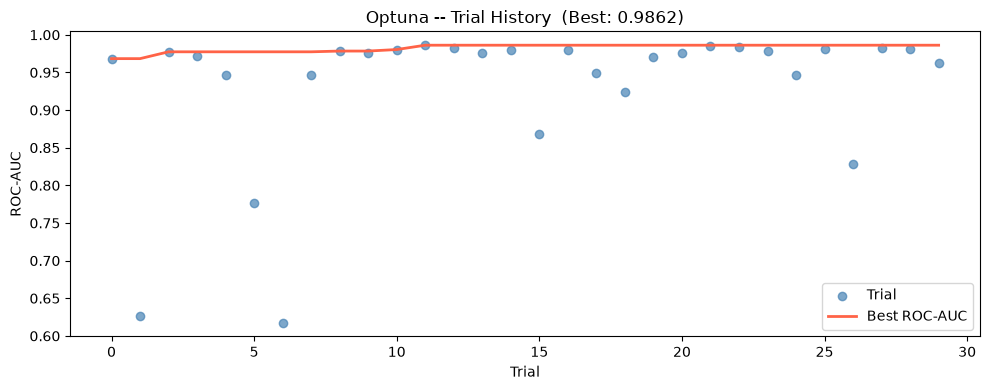


Top-5 Trials:
   value  params_dropout  params_latent_dim  params_lr  params_lstm_units
0.986191             0.0                 64   0.001257                128
0.984896             0.0                 64   0.001053                128
0.983890             0.0                 64   0.001443                128
0.982883             0.0                 32   0.001473                128
0.982883             0.0                 64   0.001348                128


In [15]:
trials_df = study.trials_dataframe()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(trials_df.index, trials_df['value'], alpha=0.7, color='steelblue', label='Trial')
ax.plot(trials_df.index, trials_df['value'].cummax(), color='tomato', linewidth=2, label='Best ROC-AUC')
ax.set_xlabel('Trial')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Optuna -- Trial History  (Best: {study.best_value:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop-5 Trials:')
print(trials_df[['value'] + [c for c in trials_df.columns if c.startswith('params_')]]
      .sort_values('value', ascending=False)
      .head(5)
      .to_string(index=False))


In [16]:
p = study.best_params
print('Best trial:', p, '\n')

inputs     = keras.Input(shape=(n_timesteps, n_features))
x          = layers.LSTM(p['lstm_units'], return_sequences=False)(inputs)
if p['dropout'] > 0:
    x      = layers.Dropout(p['dropout'])(x)
bottleneck = layers.Dense(p['latent_dim'], activation='relu')(x)
x          = layers.RepeatVector(n_timesteps)(bottleneck)
x          = layers.LSTM(p['lstm_units'], return_sequences=True)(x)
if p['dropout'] > 0:
    x      = layers.Dropout(p['dropout'])(x)
outputs    = layers.TimeDistributed(layers.Dense(n_features))(x)

best_model = keras.Model(inputs, outputs)
best_model.compile(optimizer=keras.optimizers.Adam(p['lr']), loss='mse')
best_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50, batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=1
)

def recon_err(m, X):
    return np.mean(np.square(X - m.predict(X, verbose=0)), axis=(1, 2))

test_good_err_best = recon_err(best_model, X_test_good)
bad_err_best       = recon_err(best_model, X_bad_seq)
y_sc_best          = np.concatenate([test_good_err_best, bad_err_best])
y_tr_best          = np.array([0] * len(test_good_err_best) + [1] * len(bad_err_best))

auc_best           = roc_auc_score(y_tr_best, y_sc_best)

prec_b, rec_b, thr_b = precision_recall_curve(y_tr_best, y_sc_best, pos_label=1)
f1_b        = 2 * (prec_b * rec_b) / (prec_b * rec_b + 1e-8)
thr_f1_best = thr_b[np.argmax(f1_b)]

y_pred_best = (y_sc_best > thr_f1_best).astype(int)
rep_best    = classification_report(y_tr_best, y_pred_best, target_names=['Good', 'Bad'], output_dict=True)

print('\n' + '=' * 60)
print('  BEST MODEL (Optuna)')
print('=' * 60)
print(f'\n  ROC-AUC: {auc_best:.4f}\n')
print(f'  {"":22}  {"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>6}')
print(f'  {"-"*22}  {"-"*10}  {"-"*10}  {"-"*8}  {"-"*6}')
print(f'  {"F1-optimal":22}  {thr_f1_best:>10.6f}  {rep_best["Bad"]["precision"]:>10.2%}  {rep_best["Bad"]["recall"]:>8.2%}  {rep_best["Bad"]["f1-score"]:>6.4f}')
print('=' * 60)


Best trial: {'latent_dim': 64, 'lstm_units': 128, 'dropout': 0.0, 'lr': 0.0012568782848495397} 

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.2846 - val_loss: 0.0994
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0937 - val_loss: 0.0813
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0779 - val_loss: 0.0717
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0686 - val_loss: 0.0636
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0625 - val_loss: 0.0595
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0596 - val_loss: 0.0578
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0560 - val_loss: 0.0491
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0615 - val_loss: 0.0575
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0482 - val_loss: 0.0331
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0321 - val_loss: 0.0204
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 

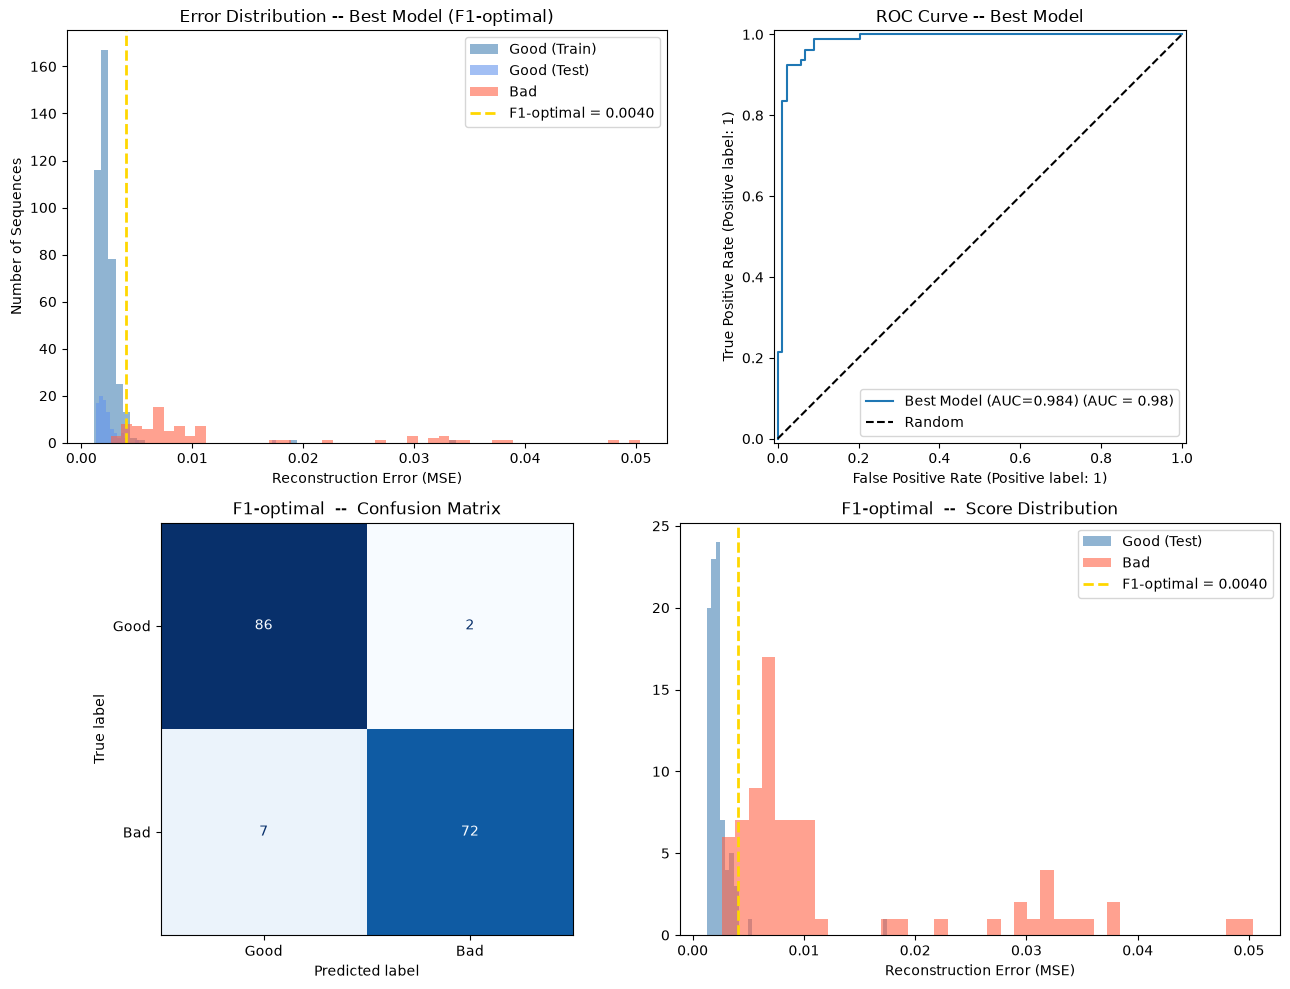

Threshold (F1-optimal): 0.004043
ROC-AUC:                0.9836

              precision    recall  f1-score   support

        Good       0.92      0.98      0.95        88
         Bad       0.97      0.91      0.94        79

    accuracy                           0.95       167
   macro avg       0.95      0.94      0.95       167
weighted avg       0.95      0.95      0.95       167



In [17]:
train_err_best = recon_err(best_model, X_train)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].hist(train_err_best,     bins=50, alpha=0.6, label='Good (Train)', color='steelblue')
axes[0, 0].hist(test_good_err_best, bins=50, alpha=0.6, label='Good (Test)',  color='cornflowerblue')
axes[0, 0].hist(bad_err_best,       bins=50, alpha=0.6, label='Bad',          color='tomato')
axes[0, 0].axvline(thr_f1_best, color='gold', linestyle='--', linewidth=2,
                   label=f'F1-optimal = {thr_f1_best:.4f}')
axes[0, 0].set_xlabel('Reconstruction Error (MSE)')
axes[0, 0].set_ylabel('Number of Sequences')
axes[0, 0].set_title('Error Distribution -- Best Model (F1-optimal)')
axes[0, 0].legend()

RocCurveDisplay.from_predictions(
    y_tr_best, y_sc_best,
    name=f'Best Model (AUC={auc_best:.3f})',
    ax=axes[0, 1]
)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_title('ROC Curve -- Best Model')
axes[0, 1].legend()

ConfusionMatrixDisplay(
    confusion_matrix(y_tr_best, y_pred_best),
    display_labels=['Good', 'Bad']
).plot(ax=axes[1, 0], colorbar=False, cmap='Blues')
axes[1, 0].set_title('F1-optimal  --  Confusion Matrix')

axes[1, 1].hist(test_good_err_best, bins=40, alpha=0.6, label='Good (Test)', color='steelblue')
axes[1, 1].hist(bad_err_best,       bins=40, alpha=0.6, label='Bad',         color='tomato')
axes[1, 1].axvline(thr_f1_best, color='gold', linestyle='--', linewidth=2,
                   label=f'F1-optimal = {thr_f1_best:.4f}')
axes[1, 1].set_xlabel('Reconstruction Error (MSE)')
axes[1, 1].set_title('F1-optimal  --  Score Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

y_pred_f1 = (y_sc_best > thr_f1_best).astype(int)
tn, fp, fn, tp = confusion_matrix(y_tr_best, y_pred_f1).ravel()

print(f'Threshold (F1-optimal): {thr_f1_best:.6f}')
print(f'ROC-AUC:                {auc_best:.4f}\n')
print(classification_report(y_tr_best, y_pred_f1, target_names=['Good', 'Bad']))

---

<a id="validation-on-unseen-recordings"></a>
## Validation on Unseen Recordings

The split above puts strokes from **every** recording into training, so the model is only ever asked whether a *known* rower looks normal. But an autoencoder flags whatever it cannot reconstruct, and **"unfamiliar" is not "faulty"**.

Stricter test: hold out one entire good recording, train on the rest, compare its error against the bad strokes.

- **AUC ≈ 1.0** — bad strokes stand out even next to an unseen rower → the signal is technique
- **AUC ≈ 0.5** — an unseen good recording looks as anomalous as a bad one → the signal is familiarity

In [18]:
# ── Leave-one-recording-out ─────────────────────────────────────────
# Same preprocessing as above, but kept per video instead of pooled.
by_video = {
    stem: np.array([resample_seq(s, TARGET_LEN) for s in seqs])
    for stem, (seqs, _) in raw.items()
}
good_videos = [v for v in by_video if 'BAD' not in v.upper()]

rows = []
for hold in good_videos:
    X_tr = np.concatenate([by_video[v] for v in good_videos if v != hold])

    m = build_lstm_autoencoder(TARGET_LEN, n_features, LATENT_DIM)
    m.compile(optimizer='adam', loss='mse')
    m.fit(
        X_tr, X_tr,
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        validation_split=0.15,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8, restore_best_weights=True)]
    )

    err_hold = reconstruction_error(m, by_video[hold])
    err_bad  = reconstruction_error(m, X_bad_seq)
    y_lovo   = np.concatenate([np.zeros(len(err_hold)), np.ones(len(err_bad))])

    rows.append({
        'held_out':     hold,
        'strokes':      len(err_hold),
        'err_held_out': round(err_hold.mean(), 5),
        'err_bad':      round(err_bad.mean(), 5),
        'roc_auc':      round(roc_auc_score(y_lovo, np.concatenate([err_hold, err_bad])), 3),
    })
    print(f"  done: {hold}")

df_lovo = pd.DataFrame(rows).sort_values('roc_auc', ascending=False)
print()
print(df_lovo.to_string(index=False))
print(f"\nmean ROC-AUC over held-out recordings: {df_lovo['roc_auc'].mean():.3f}")
print(f"random-split ROC-AUC (for comparison):  {auc:.3f}")

  done: cla-GOOD-fast
  done: cla-GOOD-slow-2
  done: cla-GOOD-slow
  done: man-GOOD-slow-MIRRORED-7.5min
  done: mar-GOOD-fast
  done: mar-GOOD-slow
  done: sim-GOOD-fast
  done: sim-GOOD-slow
  done: sim-GOOD-slow2

                     held_out  strokes  err_held_out  err_bad  roc_auc
                cla-GOOD-fast       87       0.00645  0.02180    0.998
              cla-GOOD-slow-2       33       0.00344  0.01250    0.960
                cla-GOOD-slow       68       0.00294  0.01318    0.948
                mar-GOOD-slow       50       0.01388  0.02606    0.766
               sim-GOOD-slow2       11       0.00694  0.01414    0.650
                mar-GOOD-fast       61       0.01557  0.02112    0.433
                sim-GOOD-fast       45       0.01894  0.02387    0.360
                sim-GOOD-slow       76       0.01431  0.01534    0.312
man-GOOD-slow-MIRRORED-7.5min      147       0.03007  0.01255    0.153

mean ROC-AUC over held-out recordings: 0.620
random-split ROC-AUC (for 

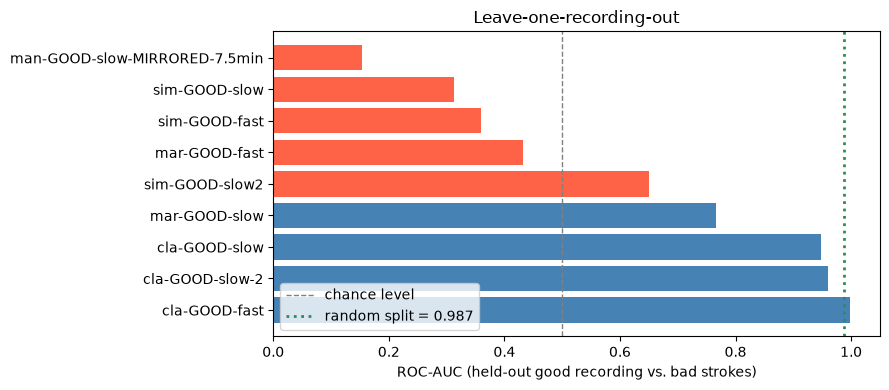

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['tomato' if v < 0.7 else 'steelblue' for v in df_lovo['roc_auc']]
ax.barh(df_lovo['held_out'], df_lovo['roc_auc'], color=colors)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='chance level')
ax.axvline(auc, color='seagreen', linestyle=':', linewidth=2, label=f'random split = {auc:.3f}')
ax.set_xlim(0, 1.05)
ax.set_xlabel('ROC-AUC (held-out good recording vs. bad strokes)')
ax.set_title('Leave-one-recording-out')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Result: the score tracks familiarity, not technique

<span style="color:#2da44e">**green**</span> = separable (AUC ≥ 0.5) · <span style="color:#cf222e">**red**</span> = not · a red *error* means the held-out good recording scored **more** anomalous than the bad strokes

| Held-out recording | Its error | Bad error | ROC-AUC |
|---|---:|---:|---:|
| cla-GOOD-fast | 0.00645 | 0.02180 | <span style="color:#2da44e">**0.998**</span> |
| cla-GOOD-slow-2 | 0.00344 | 0.01250 | <span style="color:#2da44e">**0.960**</span> |
| cla-GOOD-slow | 0.00294 | 0.01318 | <span style="color:#2da44e">**0.948**</span> |
| mar-GOOD-slow | 0.01388 | 0.02606 | <span style="color:#2da44e">**0.766**</span> |
| sim-GOOD-slow2 | 0.00694 | 0.01414 | <span style="color:#2da44e">**0.650**</span> |
| mar-GOOD-fast | 0.01557 | 0.02112 | <span style="color:#cf222e">**0.433**</span> |
| sim-GOOD-fast | 0.01894 | 0.02387 | <span style="color:#cf222e">**0.360**</span> |
| sim-GOOD-slow | 0.01431 | 0.01534 | <span style="color:#cf222e">**0.312**</span> |
| man-GOOD-slow-MIRRORED-7.5min | <span style="color:#cf222e">**0.03007**</span> | 0.01255 | <span style="color:#cf222e">**0.153**</span> |

**Mean ROC-AUC 0.620** against 0.987 on the random split — four of nine recordings below chance.

**The pattern follows the rower:** `cla` 0.969 · `mar` 0.600 · `sim` 0.441 · `man` 0.153. Every score above 0.9 belongs to `cla`, the rower the bad strokes come from — with two of his good recordings still in training the model knows his rowing and can separate the faults. For everyone else, session-to-session variation is as large as the good/bad difference.

Means alone would mislead: `sim-GOOD-slow` has the *lower* mean and still scores 0.312.

<a id="does-training-diversity-fix-it"></a>
### Does training diversity fix it?

With enough body types an unfamiliar person should stop looking anomalous. Vary **how many rowers** are in training (1, 2, 3) at a fixed 120 strokes, and track both errors.

> Runtime: ~55 short fits.

In [20]:
# ── Diversity sweep ─────────────────────────────────────────────────
import itertools

N_TRAIN_FIXED = 120                       # constant, so k measures diversity not volume
rower_of = lambda v: v.split('-')[0]
rowers   = sorted({rower_of(v) for v in good_videos})
rng      = np.random.default_rng(RANDOM_STATE)

rows_div = []
for hold in good_videos:
    others = [r for r in rowers if r != rower_of(hold)]

    for k in range(1, len(others) + 1):
        for combo in itertools.combinations(others, k):
            parts = [by_video[v] for v in good_videos
                     if rower_of(v) in combo and v != hold]
            if not parts:
                continue
            pool = np.concatenate(parts)
            if len(pool) < N_TRAIN_FIXED:            # too few strokes for a fair comparison
                continue
            X_tr = pool[rng.choice(len(pool), N_TRAIN_FIXED, replace=False)]

            m = build_lstm_autoencoder(TARGET_LEN, n_features, LATENT_DIM)
            m.compile(optimizer='adam', loss='mse')
            m.fit(
                X_tr, X_tr,
                epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0,
                validation_split=0.15,
                callbacks=[keras.callbacks.EarlyStopping(
                    monitor='val_loss', patience=8, restore_best_weights=True)]
            )

            e_hold = reconstruction_error(m, by_video[hold])
            e_bad  = reconstruction_error(m, X_bad_seq)
            y_div  = np.concatenate([np.zeros(len(e_hold)), np.ones(len(e_bad))])

            rows_div.append({
                'held_out':        hold,
                'k_rowers':        k,
                'err_unseen_good': e_hold.mean(),
                'err_bad':         e_bad.mean(),
                'roc_auc':         roc_auc_score(y_div, np.concatenate([e_hold, e_bad])),
            })
    print(f'  done: {hold}')

df_div = pd.DataFrame(rows_div)
print()
print(df_div.groupby('k_rowers').agg(
    runs            = ('roc_auc',         'size'),
    err_unseen_good = ('err_unseen_good', 'mean'),
    err_bad         = ('err_bad',         'mean'),
    mean_auc        = ('roc_auc',         'mean'),
).round(4).to_string())

  done: cla-GOOD-fast
  done: cla-GOOD-slow-2
  done: cla-GOOD-slow
  done: man-GOOD-slow-MIRRORED-7.5min
  done: mar-GOOD-fast
  done: mar-GOOD-slow
  done: sim-GOOD-fast
  done: sim-GOOD-slow
  done: sim-GOOD-slow2

          runs  err_unseen_good  err_bad  mean_auc
k_rowers                                          
1           20           0.0322   0.0420    0.6199
2           27           0.0220   0.0263    0.5064
3            9           0.0194   0.0225    0.4760


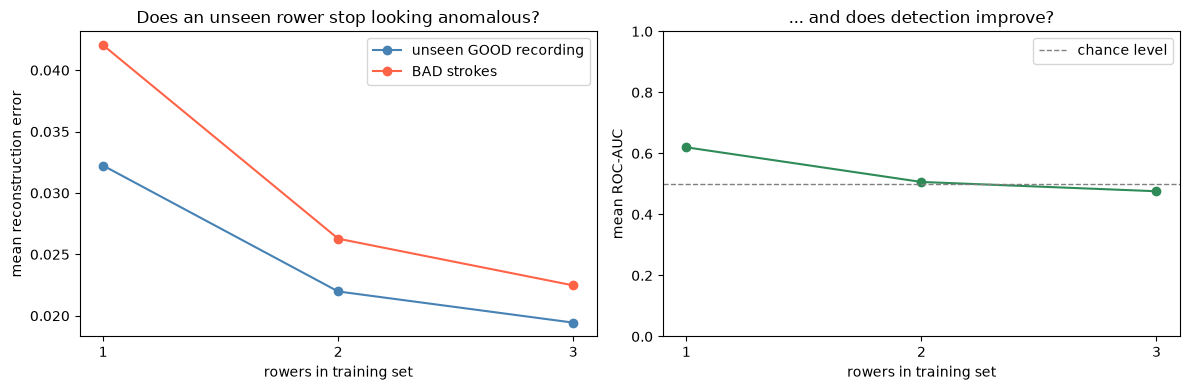

In [21]:
g = df_div.groupby('k_rowers').mean(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(g.index, g['err_unseen_good'], 'o-', color='steelblue', label='unseen GOOD recording')
axes[0].plot(g.index, g['err_bad'],         'o-', color='tomato',    label='BAD strokes')
axes[0].set_xlabel('rowers in training set')
axes[0].set_ylabel('mean reconstruction error')
axes[0].set_title('Does an unseen rower stop looking anomalous?')
axes[0].set_xticks(g.index)
axes[0].legend()

axes[1].plot(g.index, g['roc_auc'], 'o-', color='seagreen')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance level')
axes[1].set_xlabel('rowers in training set')
axes[1].set_ylabel('mean ROC-AUC')
axes[1].set_title('... and does detection improve?')
axes[1].set_xticks(g.index)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### Result: diversity removes the identity effect, but takes the signal with it

| Rowers in training | Error, unseen GOOD | Error, BAD | Mean ROC-AUC |
|---:|---:|---:|---:|
| 1 | 0.0322 | 0.0420 | <span style="color:#2da44e">**0.620**</span> |
| 2 | 0.0220 | 0.0263 | <span style="color:#2da44e">**0.506**</span> |
| 3 | 0.0194 | 0.0225 | <span style="color:#cf222e">**0.476**</span> |

The error on an unseen good recording falls from 0.0322 to 0.0194 — the model does generalize across body proportions. But the bad-stroke error falls in lockstep, 0.0420 → 0.0225, so bad strokes never become easier to pick out and the AUC drops below chance.

**A bad stroke is still rowing.** Reconstructing rowing better means reconstructing faulty rowing better too — the error was reporting *novelty*, and novelty is what diversity removes.

More good rowers will therefore not produce a technique detector. One to three rowers from the same four people: a direction, not a ceiling.

<a id="comparative-analysis"></a>
## Comparative Analysis

The Random Forest ([step 2](../2_BaselineModel/baseline_model.ipynb)) classifies single **frames** from both classes; the autoencoder scores whole **strokes** and has seen only good ones. Comparable is how each behaves when a whole recording is held out.

| Model | Optimistic split | Held-out recording |
|---|---|---|
| DummyClassifier | 0.836 accuracy | — |
| Random Forest | 0.981 accuracy, 0.998 ROC-AUC | 5.4 % of bad frames detected |
| LSTM Autoencoder | 0.987 ROC-AUC | mean ROC-AUC 0.620 |

**Improvement.** On the optimistic split both look excellent and both mislead. Held out by recording the Random Forest collapses to 5.4 %, the autoencoder stays above chance — it never sees a bad stroke, so it cannot learn to recognise the single recording they come from, whose features identify the rower with 99.6 % accuracy.

**Setback.** 0.620 is still unusable, four of nine recordings below chance.

**Conclusion.** With bad strokes from one rower, "faulty technique" and "this person" are not separable, and no architecture resolves that. Until bad recordings from several rowers exist, the held-out column is the honest one.

---

<a id="next-steps"></a>
## Next Steps

**Stage 1** — pretrain on good rowing: more videos, no labels needed.
**Stage 2** — fine-tune a classifier head on good vs. bad.

Recordings need **many different people** demonstrating **the same faults**, so the model has to find what a fault has in common. Fix the catalogue before filming:

- early arm break during the drive
- rushing the recovery
- shooting the slide
- …

~50 strokes per fault per rower ≈ 2 min of video at 22 spm.

**Caveat.** Pretraining does not remove identity: a probe on this model's bottleneck still identified the rower with 99.4 % accuracy, and a head on it detected only ~15 % of a held-out bad recording. If more people does not fix it, remove identity explicitly — an adversarial head predicting the rower, gradient reversed into the encoder.

**Validation stays leave-one-rower-out.**